### Importar Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

### Carregar Dados

In [2]:
df_vendas  = pd.read_csv('../data/processed/vendas_2023_2024_processed.csv', parse_dates=["sale_date"])
df_produtos = pd.read_csv('../data/processed/produtos_processed.csv')

In [3]:
df_vendas.head()

,id,id_client,id_product,qtd,total,sale_date,cambio
0,0,42,105,11,3405.0,2023-09-10,4.9835
1,1,3,136,9,16873.9,2024-09-15,5.5717
2,2,25,139,7,9475.3,2024-08-13,5.4875
3,4,20,23,5,55893.0,2023-02-03,5.1030
4,5,8,57,4,451403.9,2024-02-12,4.9717


In [4]:
df_produtos.head()

,code,name,price,actual_category
0,1,Transponder AIS Maré Magnum,33122.52,eletrônicos
1,2,Transponder Furuno Marlin,13998.15,eletrônicos
2,3,Radar Furuno Pulse Leviathan,9024.19,eletrônicos
3,4,Rádio AIS Hydro Tidal Zen,3381.88,eletrônicos
4,5,Piloto Automático Furuno Storm,23669.01,eletrônicos


In [5]:
produto_nome = "Motor de Popa Yamaha Evo Dash 155HP"
id_produto = df_produtos[df_produtos['name'] == produto_nome]['code'].values[0]
print(f"ID do produto {produto_nome} é ({id_produto})")

ID do produto Motor de Popa Yamaha Evo Dash 155HP é (54)


In [6]:
df_produto = df_vendas[df_vendas['id_product'] == id_produto].copy()

# df_produto.shape
df_produto.head(5)

,id,id_client,id_product,qtd,total,sale_date,cambio
46,48,13,54,15,1823022.00,2024-05-30,5.1972
53,55,35,54,3,346373.80,2024-11-24,5.8124
71,74,45,54,11,1270038.85,2024-09-25,5.4736
442,451,42,54,13,1500955.35,2024-02-19,4.9585
494,503,45,54,11,1270038.85,2024-11-27,5.8291


In [7]:
datas = pd.date_range(start=min(df_vendas["sale_date"]), end=max(df_vendas["sale_date"]), freq='D')
df_calendario = pd.DataFrame({'data': datas})
# df_calendarios

In [8]:
vendas_dia = df_produto.groupby('sale_date')['qtd'].sum().reset_index()
vendas_dia.columns = ['data', 'qtd']
vendas_dia.head()

,data,qtd
0,2023-01-10,3
1,2023-02-06,13
2,2023-02-27,15
3,2023-03-04,14
4,2023-03-15,4


In [9]:
df_venda_produto = df_calendario.merge(vendas_dia, on='data', how='left')
df_venda_produto['qtd'] = df_venda_produto['qtd'].fillna(0)

total_dias = len(df_venda_produto)
numero_vendas = df_venda_produto[df_venda_produto["qtd"] > 0]["qtd"].sum()
numero_sem_vendas = total_dias - numero_vendas

print(f"Dias totais: {total_dias}")
print(f"Dias com vendas: {numero_vendas}")
print(f"Dias sem vendas: {numero_sem_vendas}")

Dias totais: 731
Dias com vendas: 556.0
Dias sem vendas: 175.0


### Previsao usando Média Móvel

In [10]:
df_venda_produto['previsao'] = (
    df_venda_produto['qtd']
    .shift(1)                          
    .rolling(window=7, min_periods=7)
    .mean()
)

df_venda_produto = df_venda_produto.dropna()
df_venda_produto.head(10)

,data,qtd,previsao
7,2023-01-08,0.0,0.000000
8,2023-01-09,0.0,0.000000
9,2023-01-10,3.0,0.000000
10,2023-01-11,0.0,0.428571
11,2023-01-12,0.0,0.428571
12,2023-01-13,0.0,0.428571
13,2023-01-14,0.0,0.428571
14,2023-01-15,0.0,0.428571
15,2023-01-16,0.0,0.428571
16,2023-01-17,0.0,0.428571


### Treino e Teste

In [11]:
treino = df_venda_produto[df_venda_produto['data'] <= '2023-12-31'].copy()
teste = df_venda_produto[
    (df_venda_produto['data'] >= '2024-01-01') &
    (df_venda_produto['data'] <= '2024-01-31')
].copy()

print(f"Treino: {len(treino)} dias")
print(f"Teste:  {len(teste)} dias")

Treino: 358 dias
Teste:  31 dias


In [12]:
mae = mean_absolute_error(teste['qtd'], teste['previsao'])
print(f"MAE: {mae:.4f} unidades/dia")

MAE: 0.9954 unidades/dia


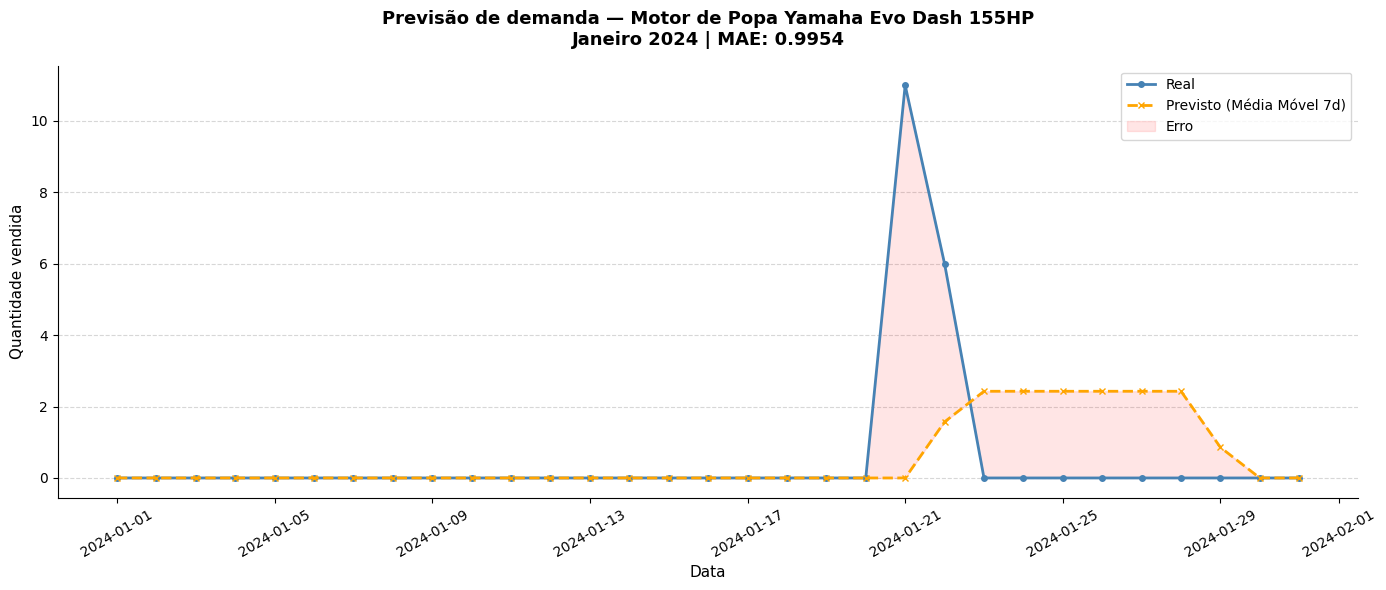

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(teste['data'], teste['qtd'],
        label='Real', color='steelblue', linewidth=2, marker='o', markersize=4)
ax.plot(teste['data'], teste['previsao'],
        label='Previsto (Média Móvel 7d)', color='orange',
        linewidth=2, linestyle='--', marker='x', markersize=4)

ax.fill_between(teste['data'], teste['qtd'], teste['previsao'],
                alpha=0.1, color='red', label='Erro')

ax.set_title(f'Previsão de demanda — {produto_nome}\nJaneiro 2024 | MAE: {mae:.4f}',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Quantidade vendida', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('../docs/reports/previsao_demanda.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
primeira_semana = teste[
    (teste['data'] >= '2024-01-01') & 
    (teste['data'] <= '2024-01-07')
]

janeiro = teste[
    (teste['data'] >= '2024-01-01') & 
    (teste['data'] <= '2024-01-31')
]

soma_previsao = round(primeira_semana['previsao'].sum())
soma_previsao_jan = round(janeiro['previsao'].sum())


print("=== Primeira semana de Janeiro 2024 ===")
print(f"Soma total da real: {primeira_semana['qtd'].sum()} unidades")
print(f"Soma total da previsão: {soma_previsao} unidades")

print("\n=== Janeiro 2024 ===")
print(f"Soma total da real: {janeiro['qtd'].sum()} unidades")
print(f"Soma total da previsão: {soma_previsao_jan} unidades")

=== Primeira semana de Janeiro 2024 ===
Soma total da real: 0.0 unidades
Soma total da previsão: 0 unidades

=== Janeiro 2024 ===
Soma total da real: 17.0 unidades
Soma total da previsão: 17 unidades
